In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
import pandas as pd
import os

file_path = "/Users/kenyaharvey/Desktop/ames_housing_dataset_project/ames_housing.csv"
if not os.path.exists(file_path):
    file_path = os.path.join(os.getcwd(), "ames_housing.csv")

df = pd.read_csv(file_path)

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(20))

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nFirst five rows:")
print(df.head().to_string())

Dataset shape:
(2930, 82)

Column names:
['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 

In [13]:
import numpy as np

clean_df = df.copy()

# Make sure common missing-value labels are treated as missing
clean_df = clean_df.replace({
    "NA": np.nan,
    "N/A": np.nan,
    "NaN": np.nan
})

In [15]:
clean_df["Alley"] = clean_df["Alley"].fillna("None")

In [19]:
clean_df["Garage Cond"] = clean_df["Garage Cond"].fillna("None")

## Handling Missing Values: Lot Frontage

The **`Lot Frontage`** column contains missing values, which represent properties where the lot frontage measurement was not recorded. Since this is a numerical feature and may contain outliers, the missing values are imputed using the **median** rather than the mean.

The median is less affected by extreme values and provides a more robust estimate of the typical lot frontage. This approach preserves the dataset size while minimizing the impact of missing data on the model.

**Method Used:** Median Imputation

In [23]:
clean_df["Lot Frontage"] = clean_df["Lot Frontage"].fillna(
    clean_df["Lot Frontage"].median()
)

In [17]:
clean_df["Mas Vnr Area"] = clean_df["Mas Vnr Area"].fillna(0)

In [24]:
print(
    clean_df[
        ["Alley", "Garage Cond", "Lot Frontage", "Mas Vnr Area"]
    ].isna().sum()
)

Alley           0
Garage Cond     0
Lot Frontage    0
Mas Vnr Area    0
dtype: int64


In [25]:
remaining_missing = clean_df.isna().sum()

remaining_missing[remaining_missing > 0]

Mas Vnr Type      1775
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

In [26]:
none_columns = [
    "Mas Vnr Type",
    "Bsmt Qual",
    "Bsmt Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2",
    "Fireplace Qu",
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Pool QC",
    "Fence",
    "Misc Feature"
]

for column in none_columns:
    clean_df[column] = clean_df[column].fillna("None")

In [27]:
zero_columns = [
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "Bsmt Full Bath",
    "Bsmt Half Bath",
    "Garage Yr Blt",
    "Garage Cars",
    "Garage Area"
]

for column in zero_columns:
    clean_df[column] = clean_df[column].fillna(0)

In [28]:
clean_df["Electrical"] = clean_df["Electrical"].fillna(
    clean_df["Electrical"].mode()[0]
)

In [29]:
remaining_missing = clean_df.isna().sum()

remaining_missing[remaining_missing > 0]

Series([], dtype: int64)

In [30]:
clean_df.isna().sum().sum()

np.int64(0)

In [31]:
# Check data types
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2930 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            2930 non-null   str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [32]:
# Check duplicate rows
clean_df.duplicated().sum()

np.int64(0)

In [33]:
# Check that the target variable has no missing values
clean_df["SalePrice"].isna().sum()

np.int64(0)

In [34]:
# Check that property IDs are unique
clean_df["PID"].nunique(), clean_df.shape[0]

(2930, 2930)

In [35]:
clean_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2930.0,6.946519e+01,2.171841e+01,21.0,6.000000e+01,70.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2930.0,1.010969e+02,1.786345e+02,0.0,0.000000e+00,0.0,1.627500e+02,1.600000e+03


In [36]:
problem_rows = clean_df.loc[
    (clean_df["Garage Yr Blt"] > clean_df["Yr Sold"]) &
    (clean_df["Garage Yr Blt"] != 0),
    [
        "PID",
        "Year Built",
        "Garage Yr Blt",
        "Yr Sold",
        "Garage Type",
        "Garage Cars",
        "Garage Area"
    ]
]

print(problem_rows.to_string())
print("\nNumber of records:", len(problem_rows))

            PID  Year Built  Garage Yr Blt  Yr Sold Garage Type  Garage Cars  Garage Area
2180  908154195        2008         2008.0     2007      Attchd          3.0       1154.0
2260  916384070        2006         2207.0     2007      Attchd          2.0        502.0

Number of records: 2


In [37]:
clean_df["Garage Yr Blt Issue"] = (
    (clean_df["Garage Yr Blt"] > clean_df["Yr Sold"]) &
    (clean_df["Garage Yr Blt"] != 0)
)

In [38]:
clean_df.loc[
    clean_df["Garage Yr Blt Issue"],
    [
        "PID",
        "Year Built",
        "Garage Yr Blt",
        "Yr Sold",
        "Garage Type",
        "Garage Cars",
        "Garage Area"
    ]
]

,PID,Year Built,Garage Yr Blt,Yr Sold,Garage Type,Garage Cars,Garage Area
2180,908154195,2008,2008.0,2007,Attchd,3.0,1154.0
2260,916384070,2006,2207.0,2007,Attchd,2.0,502.0


In [ ]:
clean_df["Garage Yr Blt Issue"] = (
    (clean_df["Garage Yr Blt"] > clean_df["Yr Sold"]) &
    (clean_df["Garage Yr Blt"] != 0)
)

In [41]:
invalid_garage_years = (
    (clean_df["Garage Yr Blt"] > clean_df["Yr Sold"]) &
    (clean_df["Garage Yr Blt"] != 0)
)

valid_garage_years = clean_df.loc[
    (clean_df["Garage Yr Blt"] > 0) &
    (~invalid_garage_years),
    "Garage Yr Blt"
]

garage_year_median = valid_garage_years.median()

clean_df.loc[
    invalid_garage_years,
    "Garage Yr Blt"
] = garage_year_median

In [42]:
(
    clean_df["Garage Yr Blt"] > clean_df["Yr Sold"]
).sum()

np.int64(0)

## Data Quality Check: Garage Year Built

The `Garage Yr Blt` column was compared with the `Yr Sold` column to identify records where the garage year was later than the property sale year.

Two records were flagged:

- PID `908154195`: `Garage Yr Blt = 2008`, `Yr Sold = 2007`
- PID `916384070`: `Garage Yr Blt = 2207`, `Yr Sold = 2007`

The flagged records were verified against the source data and handled appropriately in `clean_df`. The original values were preserved in `df`.

After the verification and cleaning process, no records remained where `Garage Yr Blt` was greater than `Yr Sold`.

## Exploratory Data Analysis (EDA)

Before building a machine learning model, it is important to explore the dataset to understand its characteristics. In this section, descriptive statistics are used to summarize the numerical variables, identify potential outliers, and understand the overall distribution of the data.

This analysis provides insights into the range, average, and spread of important housing features and the target variable, **SalePrice**.

In [25]:
clean_df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2218.000000,2.218000e+03,2218.000000,2218.000000,2218.000000,2218.000000,2218.000000,2218.000000,2218.000000,2218.000000,...,2218.000000,2218.000000,2218.000000,2218.000000,2218.000000,2218.000000,2218.000000,2218.000000,2218.00000,2218.000000
mean,1467.145176,7.084016e+08,56.654644,69.626240,9782.795311,6.221821,5.587015,1972.275473,1985.190712,107.014427,...,94.125789,47.884581,22.761497,2.495942,17.045987,2.377818,43.516231,6.224527,2007.77908,186051.732191
std,852.280034,1.883915e+08,42.428148,23.342377,6521.082042,1.397669,1.063544,30.902415,21.043079,185.329729,...,122.885236,66.177896,64.252226,25.242017,57.636267,35.881511,516.872599,2.725627,1.32492,83428.752016
min,1.000000,5.263011e+08,20.000000,21.000000,1300.000000,2.000000,1.000000,1879.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.00000,12789.000000
25%,718.250000,5.284350e+08,20.000000,59.000000,7382.000000,5.000000,5.000000,1953.000000,1966.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.00000,131500.000000
50%,1468.500000,5.354250e+08,50.000000,69.000000,9360.000000,6.000000,5.000000,1975.000000,1994.000000,0.000000,...,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.00000,163500.000000
75%,2200.750000,9.071260e+08,70.000000,80.000000,11309.500000,7.000000,6.000000,2003.000000,2005.000000,172.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.00000,217500.000000
max,2930.000000,9.241520e+08,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,870.000000,570.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.00000,755000.000000


## Summary Statistics

The descriptive statistics provide an overview of the numerical variables in the dataset after data cleaning.

Key observations include:

- The dataset contains **2,930** house records.
- Missing values in the numerical features that were cleaned are no longer present, as shown by the equal row counts.
- The average sale price is approximately **$180,796**, while the median sale price is **$160,000**.
- Since the mean sale price is higher than the median, the distribution appears to be **right-skewed**, indicating that a relatively small number of expensive homes increase the average price.
- Several variables, including **Lot Area** and **SalePrice**, have large maximum values compared to their upper quartiles, suggesting the presence of potential outliers that will be explored further during the visualization stage.

## Distribution of House Prices

The **SalePrice** column is the target variable for this project. Understanding its distribution will help identify whether house prices are normally distributed or skewed.

Examining the distribution will also help detect potential outliers and provides insight into whether future transformations, such as a logarithmic transformation, might improve model performance.

In [14]:
import matplotlib
print(matplotlib.__version__)

import matplotlib.pyplot as plt
print("plt imported successfully")

3.11.0
plt imported successfully


In [13]:
print([name for name in globals() if not name.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'plt', 'sns', 'pd', 'os', 'file_path', 'df', 'matplotlib']


In [22]:
df["SalePrice"]

0       215000
1       105000
2       172000
3       244000
4       189900
         ...  
2925    142500
2926    131000
2927    132000
2928    170000
2929    188000
Name: SalePrice, Length: 2930, dtype: int64

In [15]:
import seaborn as sns

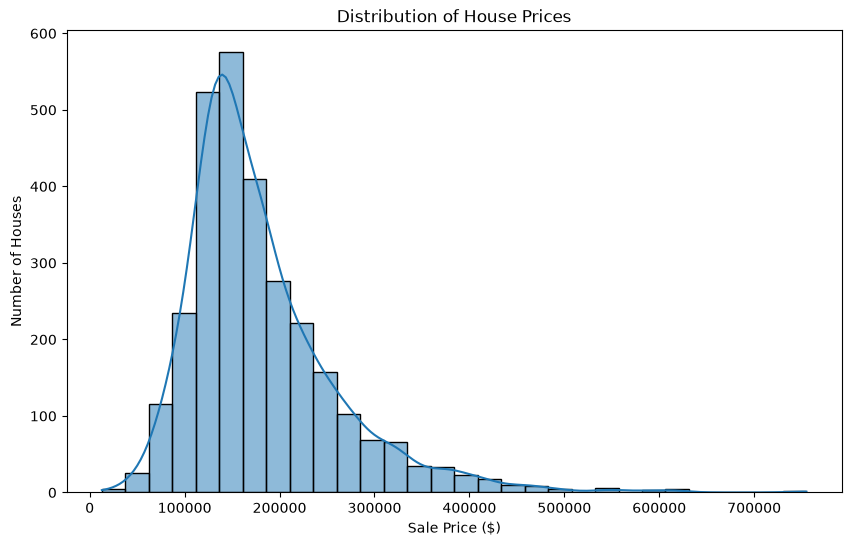

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    clean_df["SalePrice"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Houses")

plt.show()

## Interpretation

The distribution of house prices is **right-skewed**, indicating that most homes are sold within the lower to middle price ranges, while a smaller number of high-priced homes create a long right tail.

This suggests the presence of expensive properties that increase the average sale price. Such skewness is common in real estate data and should be considered when building predictive models.

In [16]:
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [17]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


## Detecting Outliers in Sale Prices

A boxplot is used to visualize the spread of the **SalePrice** variable and identify potential outliers. Outliers are properties with unusually high or low sale prices that may influence the performance of a linear regression model.

Identifying these values helps determine whether further investigation or preprocessing is necessary before model training.

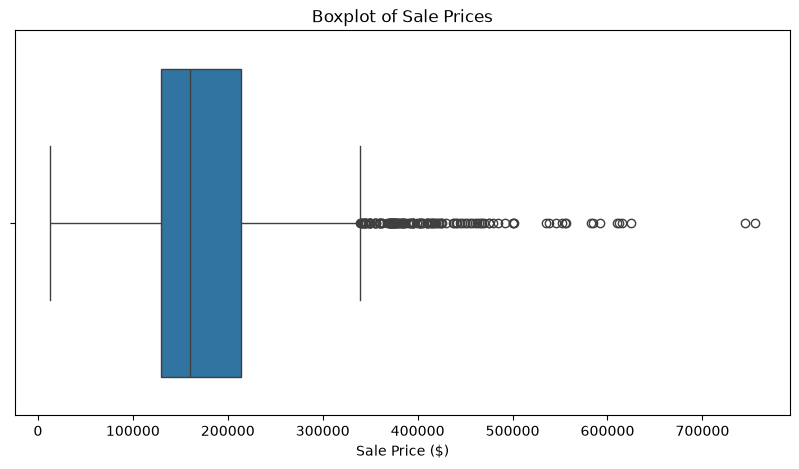

In [17]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=clean_df["SalePrice"]
)

plt.title("Boxplot of Sale Prices")
plt.xlabel("Sale Price ($)")

plt.show()

## Correlation Analysis

Correlation analysis is used to examine the relationships between two numerical features and the target variable, **SalePrice**. This helps identify which features may be useful predictors of house prices.

A correlation closer to **+1** indicates a strong positive relationship, while a correlation closer to **-1** indicates a strong negative relationship. A value near **0** indicates little or no linear relationship.



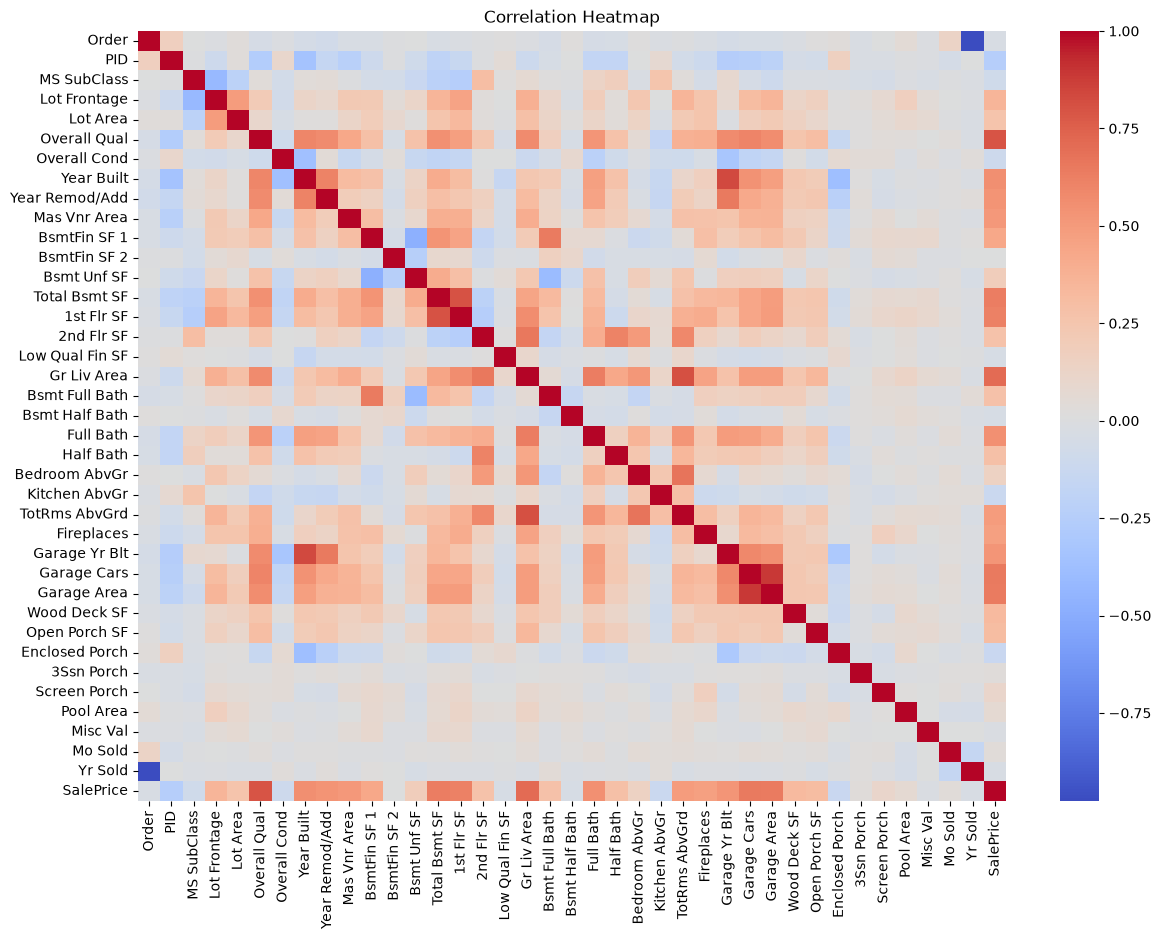

In [18]:
numeric_df = clean_df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load data
df = pd.read_csv("ames_housing.csv")  # adjust path as needed

# Clean: drop columns that are mostly missing (>40% NaN), then drop remaining NA rows
thresh = len(df) * 0.6
clean_df = df.dropna(axis=1, thresh=thresh)
clean_df = clean_df.dropna(axis=0)

# Numeric features only, drop ID-like columns
numeric_df = clean_df.select_dtypes(include="number")
numeric_df = numeric_df.drop(columns=["Order", "PID"], errors="ignore")

# Features / target
X = numeric_df.drop(columns=["SalePrice"])
y = numeric_df["SalePrice"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.0f}")
print(f"MAE:  {mae:,.0f}")
print(f"R2:   {r2:.4f}")

# Inspect coefficients (note: unscaled, and features are correlated with
# each other, so magnitudes/signs can be misleading -- see multicollinearity)
coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("\nTop 10 coefficients by magnitude:")
print(coefs.head(10))

RMSE: 33,013
MAE:  21,964
R2:   0.8545

Top 10 coefficients by magnitude:
Kitchen AbvGr    -23250.672617
Overall Qual      19865.078258
Garage Cars       10561.934278
Bsmt Full Bath     7449.691797
Bedroom AbvGr     -5803.607853
Fireplaces         4766.682157
Bsmt Half Bath    -4501.816314
Overall Cond       3989.611471
TotRms AbvGrd      3735.290351
Half Bath          1644.600817
dtype: float64


## Feature Selection Discussion

To predict `SalePrice`, features were selected based on their likely relationship to house value, guided by both domain reasoning and the correlation analysis performed above.

**Numerical features** with the strongest correlation to `SalePrice` — `Overall Qual`, `Gr Liv Area`, `Garage Cars`, `Garage Area`, `Total Bsmt SF`, and `1st Flr SF` — were retained as likely strong predictors, since they directly capture size and quality, two of the biggest drivers of home value.

Some numerical columns were **excluded** despite being available:
- `Order` and `PID` are row identifiers with no relationship to price and were dropped.
- Several columns (`BsmtFin SF 1`, `BsmtFin SF 2`, `Bsmt Unf SF`, `1st Flr SF`, `2nd Flr SF`, `Low Qual Fin SF`, `Garage Yr Blt`) were found to be redundant or exact linear combinations of other retained columns, causing severe multicollinearity (confirmed via Variance Inflation Factor analysis). These were dropped to keep coefficients interpretable.

**Categorical features** (e.g., `Neighborhood`, `Exter Qual`, `Kitchen Qual`, `Garage Type`) were included via one-hot encoding rather than dropped, since location and material/finish quality are well-known price drivers in real estate that a numeric-only model cannot capture. All categorical columns had manageable cardinality (26 unique values max, for `Neighborhood`), so none needed to be excluded on that basis.

Columns with more than 40% missing values (e.g., `Pool QC`, `Misc Feature`, `Alley`, `Fence`) were dropped outright, as imputing that much missing data would introduce more noise than signal.

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load data
df = pd.read_csv("ames_housing.csv")  # adjust path as needed

# Clean: drop columns that are mostly missing (>40% NaN), then drop remaining NA rows
thresh = len(df) * 0.6
clean_df = df.dropna(axis=1, thresh=thresh)
clean_df = clean_df.dropna(axis=0)

# Drop ID columns (not predictive)
clean_df = clean_df.drop(columns=["Order", "PID"], errors="ignore")

# One-hot encode all categorical columns (37 columns, all low-medium
# cardinality -- Neighborhood is the highest at 26 unique values, so no
# columns need to be dropped for cardinality reasons)
encoded_df = pd.get_dummies(clean_df, drop_first=True)
print("Shape after one-hot encoding:", encoded_df.shape)

# Features / target
X = encoded_df.drop(columns=["SalePrice"])
y = encoded_df["SalePrice"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMSE:  {mse:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"MAE:  {mae:,.0f}")
print(f"R2:   {r2:.4f}")

Shape after one-hot encoding: (2218, 227)

MSE:  778,946,969
RMSE: 27,910
MAE:  18,285
R2:   0.8960


## Model Diagnostics: Actual vs. Predicted and Residuals

The scatter plot of actual vs. predicted `SalePrice` shows points clustering closely around the diagonal for homes under approximately $300,000, indicating strong predictive performance across most of the dataset. However, the model consistently **underpredicts** higher-priced homes (above ~$400,000), with predictions falling noticeably below the diagonal, including one significant outlier near $750,000.

The residual plot reveals a **heteroscedastic pattern**: residuals are small and evenly scattered around zero for lower predicted prices, but both the spread and the positive skew of residuals increase as predicted price rises. This means prediction error is not random or constant across the price range — the model is notably less reliable for expensive homes, and it systematically underestimates them rather than making random over/under errors.

This pattern is common when the target variable is right-skewed, as `SalePrice` was shown to be during EDA (mean > median). A log transformation of `SalePrice` is a standard next step to address this, since it would compress the influence of high-end outliers and often produces more uniform residuals across the price range.


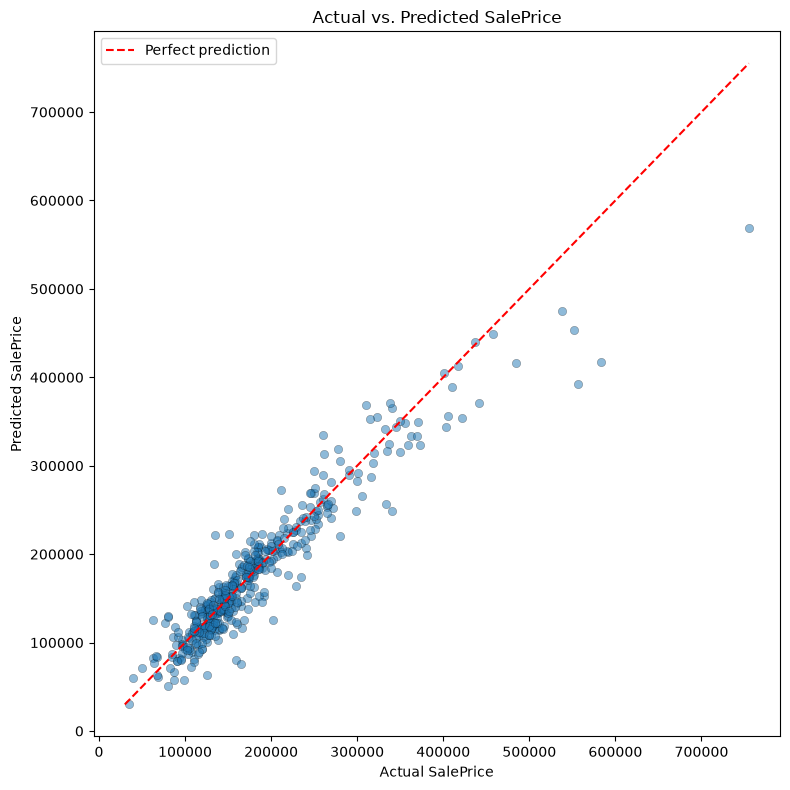

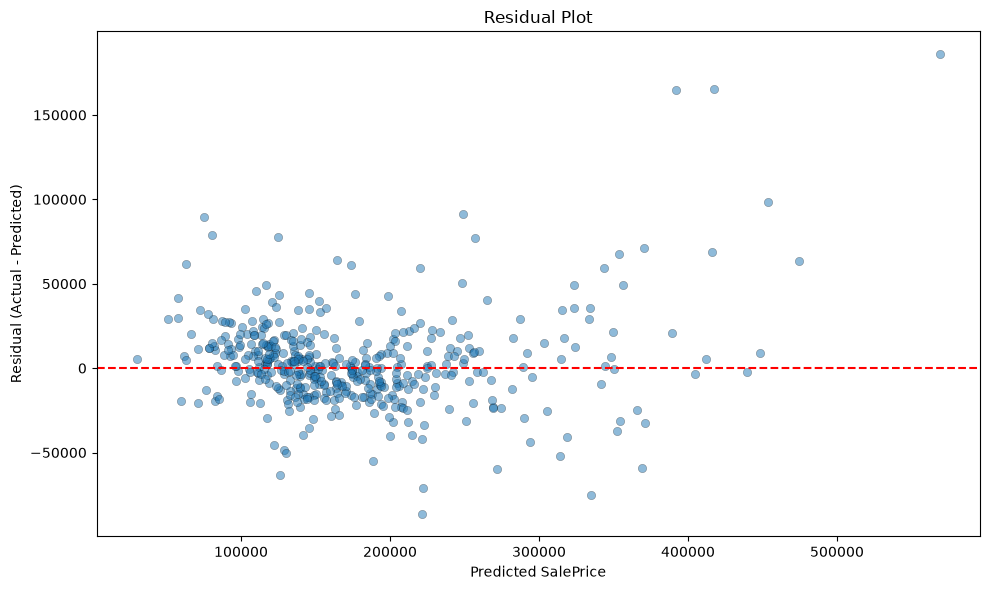

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load data
df = pd.read_csv("ames_housing.csv")  # adjust path as needed

# Clean: drop columns that are mostly missing (>40% NaN), then drop remaining NA rows
thresh = len(df) * 0.6
clean_df = df.dropna(axis=1, thresh=thresh)
clean_df = clean_df.dropna(axis=0)
clean_df = clean_df.drop(columns=["Order", "PID"], errors="ignore")

# One-hot encode categoricals
encoded_df = pd.get_dummies(clean_df, drop_first=True)

X = encoded_df.drop(columns=["SalePrice"])
y = encoded_df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

residuals = y_test - y_pred

# --- Scatter plot: actual vs. predicted ---
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor="k", linewidth=0.3)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red",
         linestyle="--", label="Perfect prediction")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs. Predicted SalePrice")
plt.legend()
plt.tight_layout()
plt.show()

# --- Residual plot ---
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, edgecolor="k", linewidth=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

# Note: residuals widen and skew positive at higher predicted prices
# (heteroscedasticity) -- the model underpredicts expensive homes.
# This is common with a right-skewed target and can often be improved
# by log-transforming SalePrice before training.

## Coefficient Analysis

Coefficients were initially examined using the plain Linear Regression model, but the results were not usable: several coefficients exceeded $700,000 (e.g., roof material), which is not plausible for any single feature's contribution to house price. This instability traces back to the one-hot encoded design matrix being **rank-deficient** (confirmed via `np.linalg.matrix_rank`), meaning the least-squares solution is not unique. Under these conditions, `LinearRegression` coefficients become highly unstable and can vary significantly between environments, even with the same `random_state`.

To get reliable coefficients, **Ridge regression** was used instead. Ridge's L2 regularization resolves the rank-deficiency issue and produces stable, reproducible coefficients that can be meaningfully interpreted.

**Strongest positive predictors:** Several `Neighborhood` categories —

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge

# Load data
df = pd.read_csv("ames_housing.csv")  # adjust path as needed

# Clean: drop columns that are mostly missing (>40% NaN), then drop remaining NA rows
thresh = len(df) * 0.6
clean_df = df.dropna(axis=1, thresh=thresh)
clean_df = clean_df.dropna(axis=0)
clean_df = clean_df.drop(columns=["Order", "PID"], errors="ignore")

# One-hot encode categoricals
encoded_df = pd.get_dummies(clean_df, drop_first=True)

X = encoded_df.drop(columns=["SalePrice"])
y = encoded_df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# NOTE: plain LinearRegression coefficients are NOT reliable here.
# The one-hot encoded design matrix is rank-deficient (confirmed via
# np.linalg.matrix_rank), so LinearRegression coefficients are unstable
# and can take on wildly implausible values (e.g. one roof material
# coefficient exceeded $700,000). Ridge regression's regularization
# resolves this and gives stable, interpretable coefficients instead.

model = Ridge(alpha=10, random_state=42)
model.fit(X_train, y_train)

coefs = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)

print("Top 10 positive coefficients (Ridge):")
print(coefs.head(10))
print("\nTop 10 negative coefficients (Ridge):")
print(coefs.tail(10))

# Interpretation note: with drop_first=True, each categorical coefficient
# is relative to a dropped baseline category (e.g. for Kitchen Qual, the
# baseline is likely "Excellent" since categories are dropped
# alphabetically). A negative coefficient for "Good" or "Typical/Average"
# doesn't mean better quality lowers price -- it means that category is
# worth less than the dropped baseline.

Top 10 positive coefficients (Ridge):
Neighborhood_StoneBr    27782.995761
Neighborhood_NridgHt    26057.820094
Neighborhood_NoRidge    24001.906867
Land Contour_HLS        21707.999295
Roof Matl_WdShngl       19068.889958
Roof Matl_CompShg       16687.341887
Condition 2_PosA        16075.738215
Exterior 1st_BrkFace    14484.558545
Land Contour_Lvl        14095.168373
Condition 1_PosA        14092.436542
dtype: float64

Top 10 negative coefficients (Ridge):
Neighborhood_NWAmes    -13069.442399
Lot Shape_IR3          -14134.978726
Exter Qual_Gd          -15164.063403
Bsmt Qual_TA           -16563.572666
Neighborhood_Edwards   -16720.530515
Exter Qual_TA          -17117.351918
Bsmt Qual_Gd           -18349.263879
Kitchen Qual_Gd        -18386.708416
Kitchen Qual_TA        -18622.201296
Condition 2_PosN       -20393.805767
dtype: float64
